## Objective - to implement a recommendation system using cosine similarity on an anime dataset. 

In [313]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [315]:
df=pd.read_csv('anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 1.Data PreProcessing

In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [319]:
df.shape

(12294, 7)

In [321]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
anime_id,12294.0,14058.221653,11455.294701,1.00,3484.25,10260.50,24794.50,34527.0
rating,12064.0,6.473902,1.026746,1.67,5.88,6.57,7.18,10.0
members,12294.0,18071.338864,54820.676925,5.00,225.00,1550.00,9437.00,1013917.0


In [323]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [324]:
df['genre'] = df['genre'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['type'] = df['type'].fillna('Unknown')

In [325]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

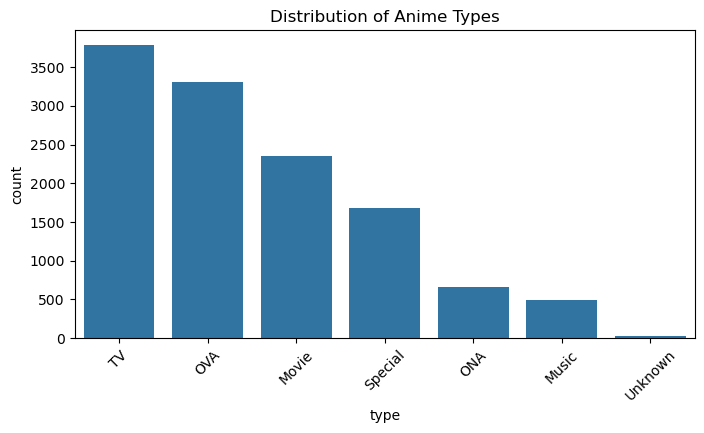

In [326]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Distribution of Anime Types')
plt.xticks(rotation=45)
plt.show()

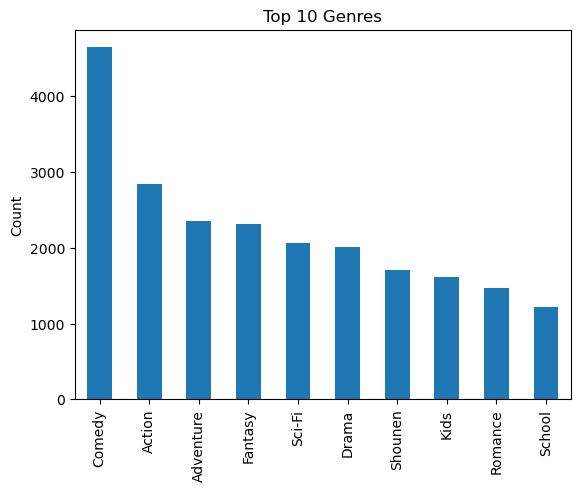

In [328]:
# Top genres
from collections import Counter
genre_list = df['genre'].str.split(', ')
flat_genres = [genre for sublist in genre_list for genre in sublist]
genre_counts = pd.Series(flat_genres).value_counts().head(10)

genre_counts.plot(kind='bar', title='Top 10 Genres')
plt.ylabel('Count')
plt.show()

# Feature Extraction & Evaluation
- genre - categorical (multi-label)
- rating - numeric (to represent popularity/quality)

In [333]:
# Step 1: Convert 'genre' into multiple binary columns
df['genre'] = df['genre'].apply(lambda x: x.split(', '))  # convert to list

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df['genre']), columns=mlb.classes_)

In [334]:
# Step 2: Normalize 'rating'
scaler = MinMaxScaler()
df['rating_scaled'] = scaler.fit_transform(df[['rating']])

In [335]:
# Step 3: Combine genre + rating into final feature matrix
features = pd.concat([genre_encoded, df['rating_scaled']], axis=1)
features.index = df.index  # align indices

In [336]:
# Optional: Save anime names with features for later reference
anime_features = pd.concat([df[['name']], features], axis=1)

In [339]:
print(anime_features.head())

                               name  Action  Adventure  Cars  Comedy  \
0                    Kimi no Na wa.       0          0     0       0   
1  Fullmetal Alchemist: Brotherhood       1          1     0       0   
2                          Gintama°       1          0     0       1   
3                       Steins;Gate       0          0     0       0   
4                     Gintama&#039;       1          0     0       1   

   Dementia  Demons  Drama  Ecchi  Fantasy  ...  Space  Sports  Super Power  \
0         0       0      1      0        0  ...      0       0            0   
1         0       0      1      0        1  ...      0       0            0   
2         0       0      0      0        0  ...      0       0            0   
3         0       0      0      0        0  ...      0       0            0   
4         0       0      0      0        0  ...      0       0            0   

   Supernatural  Thriller  Unknown  Vampire  Yaoi  Yuri  rating_scaled  
0             1    

# Build the Recommendation System using Cosine Similarity

In [346]:
cosine_sim = cosine_similarity(features)
cosine_sim

array([[1.        , 0.29880771, 0.13644987, ..., 0.15085865, 0.15492584,
        0.1737458 ],
       [0.29880771, 1.        , 0.36135915, ..., 0.11708593, 0.12024259,
        0.13484933],
       [0.13644987, 0.36135915, 1.        , ..., 0.116948  , 0.12010094,
        0.13469047],
       ...,
       [0.15085865, 0.11708593, 0.116948  , ..., 1.        , 0.99994581,
        0.99824985],
       [0.15492584, 0.12024259, 0.12010094, ..., 0.99994581, 1.        ,
        0.99881138],
       [0.1737458 , 0.13484933, 0.13469047, ..., 0.99824985, 0.99881138,
        1.        ]])

In [347]:
#Create a Series that maps anime names to their index
anime_indices = pd.Series(df.index, index=df['name']).drop_duplicates()
anime_indices

name
Kimi no Na wa.                                            0
Fullmetal Alchemist: Brotherhood                          1
Gintama°                                                  2
Steins;Gate                                               3
Gintama&#039;                                             4
                                                      ...  
Toushindai My Lover: Minami tai Mecha-Minami          12289
Under World                                           12290
Violence Gekiga David no Hoshi                        12291
Violence Gekiga Shin David no Hoshi: Inma Densetsu    12292
Yasuji no Pornorama: Yacchimae!!                      12293
Length: 12294, dtype: int64

In [350]:
#Define recommendation function
#def recommend_anime(title, top_n=10, similarity_threshold=0.5):
    # Get the index of the anime
 #   idx = anime_indices.get(title)
    
  #  if idx is None:
   #     return f"'{title}' not found in the dataset."
    
    # Get similarity scores
    #sim_scores = list(enumerate(cosine_sim[idx]))

    # Filter and sort similar animes based on score
    #sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude itself (first entry) and apply threshold
    #sim_scores = [s for s in sim_scores[1:] if s[1] >= similarity_threshold]

    # Get top_n similar anime indices
    #sim_indices = [i[0] for i in sim_scores[:top_n]]

    # Return recommended anime names
    #return df['name'].iloc[sim_indices].tolist()

In [352]:
# Print top 5 most similar anime
#for i in sim_scores[1:6]:
 #   print(df.iloc[i[0]]['name'], "with similarity score:", i[1])

In [356]:
from sklearn.model_selection import train_test_split

In [358]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [360]:
# Check shapes
print(f"Train set size: {train_df.shape}")
print(f"Test set size: {test_df.shape}")

Train set size: (9835, 8)
Test set size: (2459, 8)


In [366]:
def genre_overlap_relevance(target_genre, recommended_titles, df):
    target_genres = set(target_genre)  # Already a list
    hits = 0
    for title in recommended_titles:
        rec_genre = df[df['name'] == title]['genre'].values
        if rec_genre.size > 0:
            rec_genres = set(rec_genre[0])  # Already a list
            if target_genres & rec_genres:
                hits += 1
    return hits

In [368]:
target_anime = test_df.iloc[0]
target_title = target_anime['name']
target_genre = target_anime['genre']

idx = df[df['name'] == target_title].index[0]
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]
recommended_indices = [i[0] for i in sim_scores]
recommended_titles = df.iloc[recommended_indices]['name'].tolist()

hits = genre_overlap_relevance(target_genre, recommended_titles, df)
print(f"Relevant genre matches: {hits} out of 10 recommendations")

Relevant genre matches: 10 out of 10 recommendations


In [374]:
def evaluate_precision(test_df, df, cosine_sim, k=10):
    precisions = []

    for i in range(len(test_df)):
        target_anime = test_df.iloc[i]
        target_title = target_anime['name']
        target_genre = target_anime['genre']

        # Skip if title not found
        if target_title not in df['name'].values:
            continue

        idx = df[df['name'] == target_title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]
        recommended_indices = [i[0] for i in sim_scores]
        recommended_titles = df.iloc[recommended_indices]['name'].tolist()

        hits = genre_overlap_relevance(target_genre, recommended_titles, df)
        precision = hits / k
        precisions.append(precision)

    return sum(precisions) / len(precisions)

In [376]:
average_precision = evaluate_precision(test_df, df, cosine_sim, k=10)
print(f"Average Precision: {average_precision:.4f}")

Average Precision: 0.9998


In [378]:
def evaluate_recall(test_df, df, cosine_sim, k=10):
    recalls = []

    for i in range(len(test_df)):
        target_anime = test_df.iloc[i]
        target_title = target_anime['name']
        target_genre = target_anime['genre']

        if target_title not in df['name'].values:
            continue

        idx = df[df['name'] == target_title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]
        recommended_indices = [i[0] for i in sim_scores]
        recommended_titles = df.iloc[recommended_indices]['name'].tolist()

        hits = genre_overlap_relevance(target_genre, recommended_titles, df)

        # Count all animes in df that share at least one genre with target
        target_genres_set = set(target_genre)
        total_relevant = 0
        for g in df['genre']:
            if target_genres_set & set(g):
                total_relevant += 1

        # Avoid divide by zero
        if total_relevant > 0:
            recall = hits / total_relevant
            recalls.append(recall)

    return sum(recalls) / len(recalls)

In [380]:
average_recall = evaluate_recall(test_df, df, cosine_sim, k=10)
print(f"Average Recall: {average_recall:.4f}")

Average Recall: 0.0049


In [382]:
def evaluate_f1_score(test_df, df, cosine_sim, k=10):
    f1_scores = []

    for i in range(len(test_df)):
        target_anime = test_df.iloc[i]
        target_title = target_anime['name']
        target_genre = target_anime['genre']

        if target_title not in df['name'].values:
            continue

        idx = df[df['name'] == target_title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]
        recommended_indices = [i[0] for i in sim_scores]
        recommended_titles = df.iloc[recommended_indices]['name'].tolist()

        hits = genre_overlap_relevance(target_genre, recommended_titles, df)

        # Precision
        precision = hits / k

        # Total relevant animes
        target_genres_set = set(target_genre)
        total_relevant = 0
        for g in df['genre']:
            if target_genres_set & set(g):
                total_relevant += 1
        recall = hits / total_relevant if total_relevant > 0 else 0

        # F1 Score
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
            f1_scores.append(f1)

    return sum(f1_scores) / len(f1_scores)

In [384]:
average_f1 = evaluate_f1_score(test_df, df, cosine_sim, k=10)
print(f"Average F1-Score: {average_f1:.4f}")

Average F1-Score: 0.0095


Inter view Questions

1. Difference between user-based and item-based collaborative filtering:

- User-based: Recommends items to a user based on the behavior of similar users.
- Item-based: Recommends items that are similar to the ones a user has liked or interacted with.

2. What is collaborative filtering, and how does it work?

- Collaborative filtering: A technique that recommends items to users based on the behavior of other users with similar preferences.
- How it works: It analyzes user behavior (e.g., ratings, clicks) to identify patterns and relationships between users and items, and makes recommendations based on those patterns.